In [1]:
import pandas as pd

df = pd.read_csv("../data/application_train.csv")
df.head()
df.shape


(307511, 122)

# 1. Exploración Inicial del Dataset

Objetivo:
Comprender la estructura general del dataset Home Credit y evaluar posibles problemas de calidad de datos.

In [2]:
#df.columns.tolist()

In [3]:
df['TARGET'].value_counts()


0    282686
1     24825
Name: TARGET, dtype: int64

In [4]:
df['TARGET'].value_counts(normalize=True)*100
#Incumplen o han incumplido en el pago de sus creditos el 8% de la poblacion de estudio

0    91.927118
1     8.072882
Name: TARGET, dtype: float64

In [5]:
#missing = df.isnull().sum().sort_values(ascending=False)
#missing.head(20)

In [6]:
# Calcular porcentaje de datos faltantes
missing_pct = (df.isnull().sum()/len(df))*100
missing_pct.sort_values(ascending=False).head(20)

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
dtype: float64

In [7]:
#missing_pct[missing_pct > 50]

In [8]:
#Total datos vacios mayor al 50% = 41 variables
len(missing_pct[missing_pct > 50])

41

<AxesSubplot:>

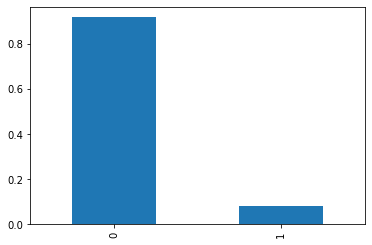

In [9]:
df['TARGET'].value_counts(normalize=True).plot(kind='bar')

### Hallazgo

El dataset contiene más de 300 mil registros y 122 variables, lo que lo convierte en una base adecuada para construir modelos de riesgo crediticio.

Pregunta responder: ¿Los clientes que incumplen tienen ingresos diferentes a los que no incumplen?

In [10]:
# Ingreso promedio por grupo
df.groupby('TARGET')['AMT_INCOME_TOTAL'].mean()

TARGET
0    169077.722266
1    165611.760906
Name: AMT_INCOME_TOTAL, dtype: float64

<AxesSubplot:title={'center':'AMT_INCOME_TOTAL'}, xlabel='TARGET'>

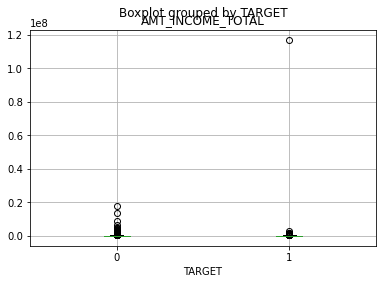

In [11]:
# Visualización
df.boxplot(column='AMT_INCOME_TOTAL', by='TARGET')

In [12]:
#Poner en formato bonito los numeros
pd.set_option('display.float_format', '{:,.2f}'.format)
#Saber si hay outliters o no
df['AMT_INCOME_TOTAL'].describe()

count       307,511.00
mean        168,797.92
std         237,123.15
min          25,650.00
25%         112,500.00
50%         147,150.00
75%         202,500.00
max     117,000,000.00
Name: AMT_INCOME_TOTAL, dtype: float64

### Hallazgo: Outliers en ingresos

La variable AMT_INCOME_TOTAL presenta valores extremos significativamente superiores a la mediana de ingresos.

El ingreso máximo registrado es de 117 millones, mientras que la mediana es cercana a 147 mil, lo que sugiere la presencia de outliers que afectan la visualización y podrían influir en algunos modelos predictivos.

<AxesSubplot:>

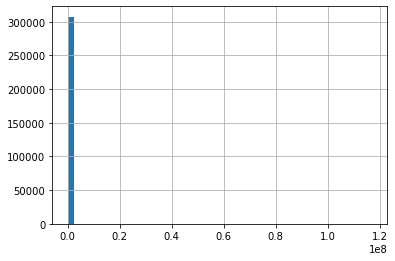

In [13]:
df['AMT_INCOME_TOTAL'].hist(bins=50)

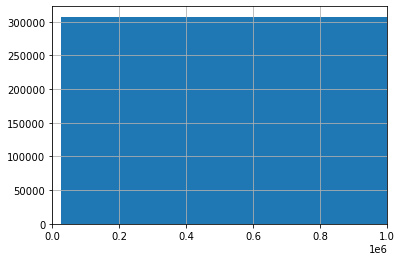

In [14]:
import matplotlib.pyplot as plt
plt.xlim(0, 1000000)
df['AMT_INCOME_TOTAL'].hist(bins=50)
plt.show()
#La segunda línea le dice al gráfico:
#"Muéstrame solo ingresos entre 0 y 1 millón."
#Así ignoramos temporalmente los valores extremos y podremos ver cómo se distribuye la mayoría de los clientes.
#Sale mal porque calcula los bins usando todos los datos, incluidos los ingresos gigantescos. Luego xlim() solo recorta la vista, pero la distribución ya quedó "aplastada".

<AxesSubplot:>

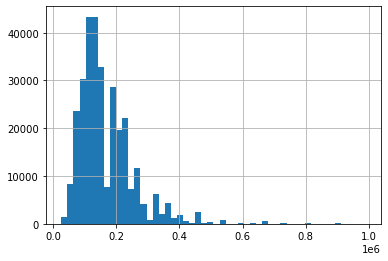

In [15]:
income_filtrado = df[df['AMT_INCOME_TOTAL'] < 1000000]

income_filtrado['AMT_INCOME_TOTAL'].hist(bins=50)
#bins = 50 hace divide ese millon en 50 cajitas. Asi cada intervalo se vuelve de 20mil usd

### Distribución de ingresos

La mayoría de los clientes presentan ingresos entre 100.000 y 250.000 unidades monetarias.

La distribución muestra una asimetría positiva, indicando que existe un grupo reducido de clientes con ingresos significativamente superiores al promedio.
La distribución está sesgada hacia la derecha.
asimetría positiva (right skewed distribution)


33333.333333333336


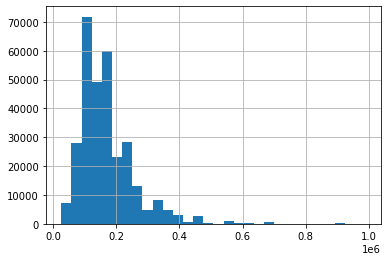

In [16]:
income_filtrado['AMT_INCOME_TOTAL'].hist(bins=30)
print(1000000/30)

Siguiente paso: ¿Qué variables están relacionadas con el incumplimiento?
Vamos a empezar mirando la edad

In [17]:
df.groupby('TARGET')['DAYS_BIRTH'].mean()
#la variable de edad viene en días y en negativo por lo que debemos convertirla

TARGET
0   -16,138.18
1   -14,884.83
Name: DAYS_BIRTH, dtype: float64

In [18]:
(df.groupby('TARGET')['DAYS_BIRTH'].mean() / -365)

TARGET
0   44.21
1   40.78
Name: DAYS_BIRTH, dtype: float64

<AxesSubplot:title={'center':'DAYS_BIRTH'}, xlabel='TARGET'>

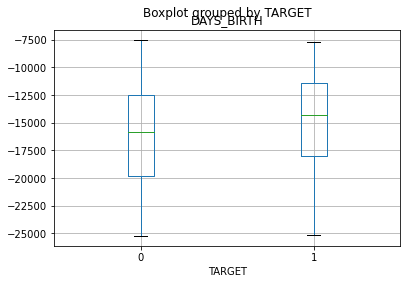

In [19]:
df.boxplot(column='DAYS_BIRTH', by='TARGET')

Lo que estamos construyendo realmente

Piensa que cada paso responde una pregunta de negocio:

Ya respondimos

✅ ¿Cuántos clientes hay?

✅ ¿Está balanceado el target?

✅ ¿Hay datos faltantes?

✅ ¿Hay outliers?

✅ ¿Cómo se distribuyen los ingresos?

### Relación entre edad e incumplimiento

Los clientes que presentan incumplimiento tienen una edad promedio de 40.8 años, mientras que los clientes sin incumplimiento presentan una edad promedio de 44.2 años.

El análisis exploratorio sugiere que los clientes más jóvenes presentan una mayor probabilidad de incumplimiento, por lo que la edad podría ser una variable relevante para los modelos predictivos.

In [20]:
(df.groupby('TARGET')['DAYS_EMPLOYED'].mean()/365)
#En Home Credit existe un valor especial:
#365243
#que se usa para representar:
#"Información de empleo desconocida" o "jubilado"
#Ese valor enorme está distorsionando el promedio.
#Por eso el boxplot muestra esos puntos gigantes arriba:

TARGET
0   179.99
1   116.15
Name: DAYS_EMPLOYED, dtype: float64

<AxesSubplot:title={'center':'DAYS_EMPLOYED'}, xlabel='TARGET'>

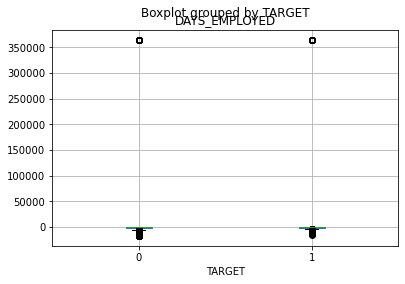

In [21]:
df.boxplot(column='DAYS_EMPLOYED', by='TARGET')

In [22]:
(df['DAYS_EMPLOYED'] == 365243).sum()
#55.374 jubilados o sin info
(df['DAYS_EMPLOYED'] == 365243).mean()*100
#El 18%

18.00716071945394

### Hallazgo: Valor especial en DAYS_EMPLOYED

Se detectó que aproximadamente el 18% de los registros presentan el valor 365243 en la variable DAYS_EMPLOYED.

Este valor no representa una cantidad real de días trabajados, sino un código especial utilizado por Home Credit para indicar situaciones particulares o información laboral no disponible.

Debido a que genera distorsiones importantes en las estadísticas descriptivas y visualizaciones, se debe tratar como valor faltante (NaN) en las etapas posteriores del análisis y modelad?

##### Pregunta:
¿Los clientes con 365243 incumplen más o menos que el resto?

In [23]:
#Creamos una nueva columna que me diga true cuando encuentre la condición
df['ANOM_EMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243)

df.groupby('ANOM_EMPLOYED')['TARGET'].mean()*100
#Agrúpame los clientes según tengan o no la anomalía y calcula el porcentaje promedio de incumplimiento.

ANOM_EMPLOYED
False   8.66
True    5.40
Name: TARGET, dtype: float64

### Hallazgo: Relación entre la anomalía de empleo e incumplimiento

Se creó una variable indicadora (ANOM_EMPLOYED) para identificar los registros con el valor especial 365243 en DAYS_EMPLOYED.

Se observó que estos clientes presentan una tasa de incumplimiento de 5.40%, significativamente menor que la observada en el resto de los clientes (8.66%).

Esto sugiere que la anomalía contiene información relevante para la predicción del riesgo crediticio y podría conservarse como una variable explicativa en etapas posteriores del modelado.

In [24]:
df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].describe()
#Se sabe que son scores externos provenientes de agencias o fuentes de información crediticia. Hacemos el supuesto de:
#Score de buró de crédito
#Score de comportamiento financiero
#Score de riesgo externo

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
count,"134,133.00","306,851.00","246,546.00"
mean,0.50,0.51,0.51
std,0.21,0.19,0.19
min,0.01,0.00,0.00
25%,0.33,0.39,0.37
50%,0.51,0.57,0.54
75%,0.68,0.66,0.67
max,0.96,0.85,0.90


In [25]:
#Vamos a comprobar que entre más alto el score más confiable a pagar es el cliente
df.groupby('TARGET')[['EXT_SOURCE_1',
                      'EXT_SOURCE_2',
                      'EXT_SOURCE_3']].mean()

,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
TARGET,,,
0,0.51,0.52,0.52
1,0.39,0.41,0.39


## Hallazgo: Los scores externos están fuertemente relacionados con el incumplimiento

### Se analizaron las variables EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3, las cuales representan puntuaciones externas de riesgo crediticio.

Se observó que los clientes que incumplen presentan valores promedio considerablemente menores en las tres variables respecto a los clientes que cumplen con sus obligaciones.

Por ejemplo:

- EXT_SOURCE_1: 0.51 vs 0.39
- EXT_SOURCE_2: 0.52 vs 0.41
- EXT_SOURCE_3: 0.52 vs 0.39

Este resultado sugiere que los scores externos poseen una fuerte capacidad predictiva y probablemente serán variables relevantes para el modelo de riesgo crediticio.

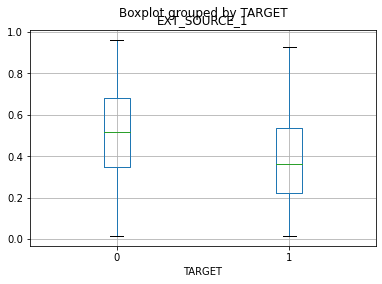

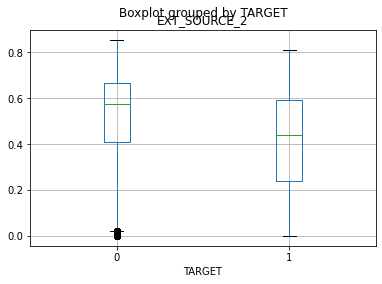

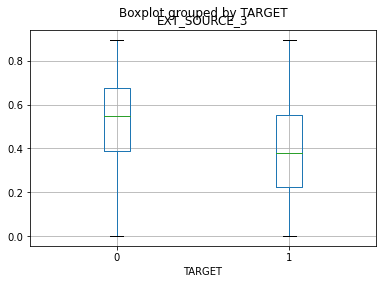

In [26]:
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    df.boxplot(column=col, by='TARGET')

In [27]:
df.groupby('TARGET')['AMT_CREDIT'].mean()

TARGET
0   602,648.28
1   557,778.53
Name: AMT_CREDIT, dtype: float64

In [28]:
(df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']).describe()

count   307,511.00
mean          3.96
std           2.69
min           0.00
25%           2.02
50%           3.27
75%           5.16
max          84.74
dtype: float64

In [29]:
(df.groupby('TARGET')
   .apply(lambda x: (x['AMT_CREDIT'] / x['AMT_INCOME_TOTAL']).mean()))

TARGET
0   3.96
1   3.89
dtype: float64

In [30]:
ratio = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

df.loc[ratio.nlargest(10).index,
       ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'TARGET']]

,AMT_INCOME_TOTAL,AMT_CREDIT,TARGET
20727,"25,650.00","2,173,500.00",1
35791,"45,000.00","2,215,224.00",0
226137,"45,000.00","1,800,000.00",1
255247,"58,500.00","2,146,500.00",1
158077,"40,500.00","1,436,850.00",0
678,"54,000.00","1,885,500.00",1
205575,"36,000.00","1,223,010.00",1
103862,"54,000.00","1,800,000.00",0
165555,"27,000.00","900,000.00",0
193574,"27,900.00","916,470.00",0


In [31]:
ratio = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

ratio.describe(percentiles=[0.90, 0.95, 0.99])

count   307,511.00
mean          3.96
std           2.69
min           0.00
50%           3.27
90%           7.49
95%           9.16
99%          13.03
max          84.74
dtype: float64

In [32]:
ratio = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

df['CREDIT_INCOME_RATIO'] = ratio

df.groupby('TARGET')['CREDIT_INCOME_RATIO'].mean()

TARGET
0   3.96
1   3.89
Name: CREDIT_INCOME_RATIO, dtype: float64

In [33]:
df.groupby('TARGET')['CREDIT_INCOME_RATIO'].median()

TARGET
0   3.27
1   3.25
Name: CREDIT_INCOME_RATIO, dtype: float64

<AxesSubplot:title={'center':'CREDIT_INCOME_RATIO'}, xlabel='TARGET'>

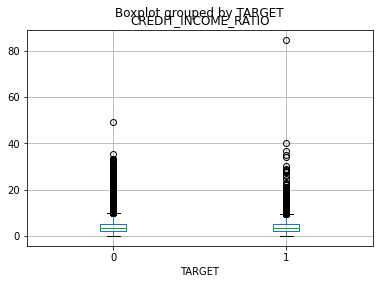

In [34]:
df.boxplot(column='CREDIT_INCOME_RATIO', by='TARGET')

Se construyó la variable CREDIT_INCOME_RATIO para medir la relación entre el monto solicitado y el ingreso anual del cliente.

Aunque existen observaciones extremas con ratios muy elevados, las distribuciones para clientes cumplidores e incumplidores son prácticamente idénticas (mediana ≈ 3.27 vs 3.25).

Esto sugiere que la relación crédito-ingreso, por sí sola, posee poca capacidad discriminativa para explicar el incumplimiento en este conjunto de datos.

In [35]:
#Miramos el comportamiento del mounthly_payment
df.groupby('TARGET')['AMT_ANNUITY'].median()

TARGET
0   24,876.00
1   25,263.00
Name: AMT_ANNUITY, dtype: float64

<AxesSubplot:title={'center':'AMT_ANNUITY'}, xlabel='TARGET'>

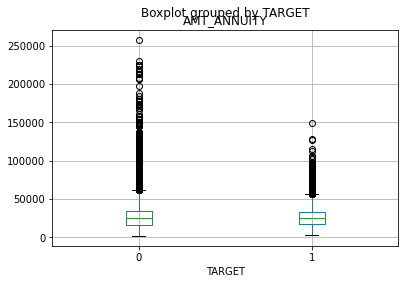

In [36]:
df.boxplot(column='AMT_ANNUITY', by='TARGET')

Esta parece no ser una variable fuerte
Ahora
#### ¿Qué tipo de cliente incumple más?

Pensionistas, empleados, empresarios, estudiantes, desempleados, etc.

In [37]:
(
    df.groupby('NAME_INCOME_TYPE')['TARGET']
      .mean()
      .sort_values(ascending=False)
      * 100
)

NAME_INCOME_TYPE
Maternity leave        40.00
Unemployed             36.36
Working                 9.59
Commercial associate    7.48
State servant           5.75
Pensioner               5.39
Businessman             0.00
Student                 0.00
Name: TARGET, dtype: float64

In [38]:
df.groupby('NAME_INCOME_TYPE').size()

NAME_INCOME_TYPE
Businessman                 10
Commercial associate     71617
Maternity leave              5
Pensioner                55362
State servant            21703
Student                     18
Unemployed                  22
Working                 158774
dtype: int64

In [39]:
df['NAME_INCOME_TYPE'].value_counts()

Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: NAME_INCOME_TYPE, dtype: int64

Se analizó la tasa de incumplimiento según el tipo de ingreso del solicitante. Aunque las categorías "Maternity leave" y "Unemployed" presentaron las mayores tasas de incumplimiento (40% y 36.4%), estas corresponden a grupos extremadamente pequeños (5 y 22 observaciones respectivamente), por lo que no permiten extraer conclusiones confiables.

Entre las categorías con representación significativa, los clientes "Working" mostraron la mayor tasa de incumplimiento (9.59%), seguidos por los "Commercial associate" (7.48%). Por otro lado, los "Pensioner" (5.39%) y "State servant" (5.75%) presentaron menores niveles de incumplimiento.

Esto sugiere que el tipo de ingreso podría aportar información relevante para la predicción del riesgo crediticio.

In [40]:
#Ahora miramos el grupo familiar como se comporta el incumplimieto
df.groupby('CNT_CHILDREN')['TARGET'].mean().sort_index() * 100

CNT_CHILDREN
0      7.71
1      8.92
2      8.72
3      9.63
4     12.82
5      8.33
6     28.57
7      0.00
8      0.00
9    100.00
10     0.00
11   100.00
12     0.00
14     0.00
19     0.00
Name: TARGET, dtype: float64

In [41]:
(
    df.groupby('CNT_CHILDREN')
      .agg(
          clientes=('TARGET','size'),
          incumplimiento=('TARGET','mean')
      )
      .assign(incumplimiento=lambda x: x['incumplimiento']*100)
)

,clientes,incumplimiento
CNT_CHILDREN,,
0,215371,7.71
1,61119,8.92
2,26749,8.72
3,3717,9.63
4,429,12.82
5,84,8.33
6,21,28.57
7,7,0.00
8,2,0.00


In [42]:
(
    df.groupby('CNT_FAM_MEMBERS')
      .agg(
          clientes=('TARGET','size'),
          incumplimiento=('TARGET','mean')
      )
      .assign(incumplimiento=lambda x: x['incumplimiento']*100)
      .sort_index()
)

,clientes,incumplimiento
CNT_FAM_MEMBERS,,
1.00,67847,8.36
2.00,158357,7.58
3.00,52601,8.76
4.00,24697,8.65
5.00,3478,9.40
6.00,408,13.48
7.00,81,7.41
8.00,20,30.00
9.00,6,0.00


Se analizó la tasa de incumplimiento según el número de hijos del solicitante. Los resultados muestran una tendencia creciente: los clientes sin hijos presentan una tasa de incumplimiento de 7.71%, mientras que aquellos con uno, dos y tres hijos registran tasas de 8.92%, 8.72% y 9.63%, respectivamente.

Este comportamiento sugiere que mayores responsabilidades familiares podrían estar asociadas con un incremento moderado del riesgo de incumplimiento. No obstante, para categorías con más de cuatro hijos el número de observaciones es reducido, por lo que dichas tasas deben interpretarse con cautela.

Se analizó la relación entre el tamaño del hogar (CNT_FAM_MEMBERS) y la tasa de incumplimiento. Los hogares de dos miembros presentaron la menor tasa de incumplimiento (7.58%), mientras que hogares más numerosos mostraron niveles progresivamente mayores de riesgo. Por ejemplo, los hogares de tres, cuatro y cinco miembros registraron tasas de incumplimiento de 8.76%, 8.65% y 9.40%, respectivamente.

Este patrón sugiere que una mayor cantidad de personas dependientes en el hogar podría incrementar la presión financiera del solicitante y, en consecuencia, el riesgo de incumplimiento. Las categorías con más de seis miembros contienen pocas observaciones y deben interpretarse con cautela.

In [43]:
df.groupby('TARGET')['AMT_ANNUITY'].describe()

,count,mean,std,min,25%,50%,75%,max
TARGET,,,,,,,,
0,"282,674.00","27,163.62","14,658.31","1,615.50","16,456.50","24,876.00","34,749.00","258,025.50"
1,"24,825.00","26,481.74","12,450.68","2,722.50","17,361.00","25,263.00","32,976.00","149,211.00"


<AxesSubplot:title={'center':'AMT_ANNUITY'}, xlabel='TARGET'>

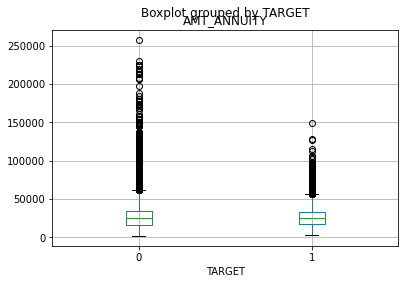

In [44]:
df.boxplot(column='AMT_ANNUITY', by='TARGET')

In [45]:
df['ANNUITY_INCOME_RATIO'] = (
    df['AMT_ANNUITY'] /
    df['AMT_INCOME_TOTAL']
)
df.groupby('TARGET')['ANNUITY_INCOME_RATIO'].median()

TARGET
0   0.16
1   0.17
Name: ANNUITY_INCOME_RATIO, dtype: float64

<AxesSubplot:title={'center':'ANNUITY_INCOME_RATIO'}, xlabel='TARGET'>

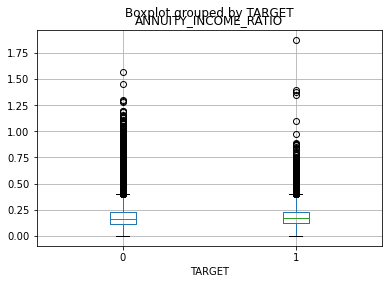

In [46]:
df.boxplot(
    column='ANNUITY_INCOME_RATIO',
    by='TARGET'
)

In [47]:
df.groupby('TARGET')['ANNUITY_INCOME_RATIO'].quantile(
    [0.25,0.5,0.75,0.9]
)

TARGET      
0       0.25   0.11
        0.50   0.16
        0.75   0.23
        0.90   0.30
1       0.25   0.12
        0.50   0.17
        0.75   0.23
        0.90   0.30
Name: ANNUITY_INCOME_RATIO, dtype: float64

In [48]:
df.groupby('NAME_HOUSING_TYPE')['TARGET'].mean().sort_values(ascending=False) * 100

NAME_HOUSING_TYPE
Rented apartment      12.31
With parents          11.70
Municipal apartment    8.54
Co-op apartment        7.93
House / apartment      7.80
Office apartment       6.57
Name: TARGET, dtype: float64

Se analizó la tasa de incumplimiento según el tipo de vivienda del solicitante. Los clientes que viven en arriendo (“Rented apartment”) y aquellos que viven con sus padres (“With parents”) presentaron las tasas de incumplimiento más altas, con 12.31% y 11.70% respectivamente. En contraste, quienes viven en una casa o apartamento propio registraron una tasa de 7.80%. > > Esto sugiere que la estabilidad habitacional y la propiedad de vivienda podrían estar asociadas con un menor riesgo crediticio. No obstante, antes de extraer conclusiones definitivas es necesario validar el tamaño de muestra de cada categoría.

In [49]:
df['NAME_HOUSING_TYPE'].value_counts()

House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: NAME_HOUSING_TYPE, dtype: int64

In [50]:
(
    df.groupby('NAME_HOUSING_TYPE')
      .agg(
          clientes=('TARGET','size'),
          incumplimiento=('TARGET','mean')
      )
      .assign(incumplimiento=lambda x: x['incumplimiento']*100)
      .sort_values('incumplimiento', ascending=False)
      #Dado que todas las categorías analizadas cuentan con un número relevante de observaciones, 
      #este resultado sugiere que la estabilidad habitacional podría estar relacionada con un menor riesgo crediticio.
)

,clientes,incumplimiento
NAME_HOUSING_TYPE,,
Rented apartment,4881,12.31
With parents,14840,11.70
Municipal apartment,11183,8.54
Co-op apartment,1122,7.93
House / apartment,272868,7.80
Office apartment,2617,6.57


In [51]:
(
    df.groupby('NAME_FAMILY_STATUS')['TARGET']
      .mean()
      .sort_values(ascending=False)
      * 100
)

NAME_FAMILY_STATUS
Civil marriage         9.94
Single / not married   9.81
Separated              8.19
Married                7.56
Widow                  5.82
Unknown                0.00
Name: TARGET, dtype: float64

In [52]:
(
    df.groupby('NAME_FAMILY_STATUS')
      .agg(
          clientes=('TARGET','size'),
          incumplimiento=('TARGET','mean')
      )
      .assign(
          incumplimiento=lambda x: x['incumplimiento'] * 100
      )
      .sort_values('incumplimiento', ascending=False)
)

,clientes,incumplimiento
NAME_FAMILY_STATUS,,
Civil marriage,29775,9.94
Single / not married,45444,9.81
Separated,19770,8.19
Married,196432,7.56
Widow,16088,5.82
Unknown,2,0.00


#### Hallazgo: el estado civil presenta asociación con el riesgo de incumplimiento.

Los clientes solteros y aquellos en unión civil presentaron las mayores tasas de incumplimiento (9.81% y 9.94%, respectivamente), mientras que los clientes casados registraron una tasa menor (7.56%). Los viudos mostraron el menor nivel de incumplimiento (5.82%).

Estos resultados sugieren que la estabilidad familiar podría estar asociada con un menor riesgo crediticio. Sin embargo, parte de esta relación podría estar influenciada por otras variables demográficas, como la edad.

In [53]:
(
    df.groupby('NAME_EDUCATION_TYPE')
      .agg(
          clientes=('TARGET','size'),
          incumplimiento=('TARGET','mean')
      )
      .assign(
          incumplimiento=lambda x: x['incumplimiento']*100
      )
      .sort_values('incumplimiento', ascending=False)
)

,clientes,incumplimiento
NAME_EDUCATION_TYPE,,
Lower secondary,3816,10.93
Secondary / secondary special,218391,8.94
Incomplete higher,10277,8.48
Higher education,74863,5.36
Academic degree,164,1.83


## Ranking hallazgos

#### Muy fuertes

EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3

#### Fuertes

Nivel educativo
Tipo de vivienda

##### Moderadas

Estado civil
Edad
Tipo de ingreso
Anomalía DAYS_EMPLOYED

#### Débiles
Número de hijos
Miembros del hogar

#### Poco útiles individualmente
AMT_CREDIT
AMT_ANNUITY
CREDIT_INCOME_RATIO
ANNUITY_INCOME_RATIO

In [54]:
df.shape

(307511, 125)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 125 entries, SK_ID_CURR to ANNUITY_INCOME_RATIO
dtypes: bool(1), float64(67), int64(41), object(16)
memory usage: 291.2+ MB


## Preparación de los datos

In [56]:
df_model = df.copy()

In [57]:
df_model.select_dtypes(include='object').columns

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [58]:
df_model.isnull().mean().sort_values(ascending=False).head(20)

COMMONAREA_MODE            0.70
COMMONAREA_AVG             0.70
COMMONAREA_MEDI            0.70
NONLIVINGAPARTMENTS_MODE   0.69
NONLIVINGAPARTMENTS_AVG    0.69
NONLIVINGAPARTMENTS_MEDI   0.69
FONDKAPREMONT_MODE         0.68
LIVINGAPARTMENTS_MODE      0.68
LIVINGAPARTMENTS_AVG       0.68
LIVINGAPARTMENTS_MEDI      0.68
FLOORSMIN_MEDI             0.68
FLOORSMIN_MODE             0.68
FLOORSMIN_AVG              0.68
YEARS_BUILD_MEDI           0.66
YEARS_BUILD_AVG            0.66
YEARS_BUILD_MODE           0.66
OWN_CAR_AGE                0.66
LANDAREA_MODE              0.59
LANDAREA_AVG               0.59
LANDAREA_MEDI              0.59
dtype: float64

In [59]:
#Eliminar columnas >65% nulos  
threshold = 0.65

cols_drop = df_model.columns[
    df_model.isnull().mean() > threshold
]

len(cols_drop)

17

In [60]:
df_model = df_model.drop(columns=cols_drop)

In [61]:
cols_drop

Index(['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG',
       'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE',
       'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE',
       'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI',
       'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI',
       'FONDKAPREMONT_MODE'],
      dtype='object')

In [62]:
df_model.shape

(307511, 108)

In [63]:
#Revisar nulos restantes
(
    df_model.isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

LANDAREA_AVG         0.59
LANDAREA_MODE        0.59
LANDAREA_MEDI        0.59
BASEMENTAREA_AVG     0.59
BASEMENTAREA_MODE    0.59
BASEMENTAREA_MEDI    0.59
EXT_SOURCE_1         0.56
NONLIVINGAREA_MEDI   0.55
NONLIVINGAREA_AVG    0.55
NONLIVINGAREA_MODE   0.55
ELEVATORS_MEDI       0.53
ELEVATORS_MODE       0.53
ELEVATORS_AVG        0.53
WALLSMATERIAL_MODE   0.51
APARTMENTS_AVG       0.51
APARTMENTS_MODE      0.51
APARTMENTS_MEDI      0.51
ENTRANCES_MEDI       0.50
ENTRANCES_MODE       0.50
ENTRANCES_AVG        0.50
dtype: float64

In [68]:
df_model['EXT_SOURCE_1_MISSING'] = (
    df_model['EXT_SOURCE_1'].isnull().astype(int)
)

df_model['EXT_SOURCE_1'] = (
    df_model['EXT_SOURCE_1']
    .fillna(df_model['EXT_SOURCE_1'].median())
)

In [69]:
df_model['EXT_SOURCE_1'].isnull().sum()

0

In [ ]:
for col in ['EXT_SOURCE_1',
            'LANDAREA_AVG',
            'BASEMENTAREA_AVG',
            'ELEVATORS_AVG']:
    
    print(col)
    print(df_model.groupby(df_model[col].isnull())['TARGET'].mean()*100)
    print()
    #los nulos tienen relación con el incumplimiento.

EXT_SOURCE_1
EXT_SOURCE_1
False   7.50
True    8.52
Name: TARGET, dtype: float64

LANDAREA_AVG
LANDAREA_AVG
False   6.98
True    8.82
Name: TARGET, dtype: float64

BASEMENTAREA_AVG
BASEMENTAREA_AVG
False   6.89
True    8.91
Name: TARGET, dtype: float64

ELEVATORS_AVG
ELEVATORS_AVG
False   6.90
True    9.10
Name: TARGET, dtype: float64



In [70]:
for col in [
    'LANDAREA_AVG',
    'BASEMENTAREA_AVG',
    'ELEVATORS_AVG'
]:
    
    df_model[col + '_MISSING'] = (
        df_model[col].isnull().astype(int)
    )

    df_model[col] = (
        df_model[col]
        .fillna(df_model[col].median())
    )

In [71]:
(
    df_model.isnull()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

LANDAREA_MODE        0.59
LANDAREA_MEDI        0.59
BASEMENTAREA_MODE    0.59
BASEMENTAREA_MEDI    0.59
NONLIVINGAREA_MEDI   0.55
NONLIVINGAREA_AVG    0.55
NONLIVINGAREA_MODE   0.55
ELEVATORS_MEDI       0.53
ELEVATORS_MODE       0.53
WALLSMATERIAL_MODE   0.51
APARTMENTS_AVG       0.51
APARTMENTS_MODE      0.51
APARTMENTS_MEDI      0.51
ENTRANCES_AVG        0.50
ENTRANCES_MODE       0.50
ENTRANCES_MEDI       0.50
LIVINGAREA_MEDI      0.50
LIVINGAREA_AVG       0.50
LIVINGAREA_MODE      0.50
HOUSETYPE_MODE       0.50
dtype: float64

In [72]:
#Borramos las variables que nos dicen lo mismo y dejamos las average
cols_redundantes = [
    'LANDAREA_MEDI','LANDAREA_MODE',
    'BASEMENTAREA_MEDI','BASEMENTAREA_MODE',
    'NONLIVINGAREA_MEDI','NONLIVINGAREA_MODE',
    'ELEVATORS_MEDI','ELEVATORS_MODE',
    'APARTMENTS_MEDI','APARTMENTS_MODE',
    'ENTRANCES_MEDI','ENTRANCES_MODE',
    'LIVINGAREA_MEDI','LIVINGAREA_MODE'
]

df_model = df_model.drop(columns=cols_redundantes)

In [73]:
df_model.isnull().mean().sort_values(ascending=False).head(20)

NONLIVINGAREA_AVG              0.55
WALLSMATERIAL_MODE             0.51
APARTMENTS_AVG                 0.51
ENTRANCES_AVG                  0.50
LIVINGAREA_AVG                 0.50
HOUSETYPE_MODE                 0.50
FLOORSMAX_MEDI                 0.50
FLOORSMAX_MODE                 0.50
FLOORSMAX_AVG                  0.50
YEARS_BEGINEXPLUATATION_MODE   0.49
YEARS_BEGINEXPLUATATION_MEDI   0.49
YEARS_BEGINEXPLUATATION_AVG    0.49
TOTALAREA_MODE                 0.48
EMERGENCYSTATE_MODE            0.47
OCCUPATION_TYPE                0.31
EXT_SOURCE_3                   0.20
AMT_REQ_CREDIT_BUREAU_MON      0.14
AMT_REQ_CREDIT_BUREAU_WEEK     0.14
AMT_REQ_CREDIT_BUREAU_YEAR     0.14
AMT_REQ_CREDIT_BUREAU_QRT      0.14
dtype: float64

In [74]:
df_model[
    [
        'WALLSMATERIAL_MODE',
        'HOUSETYPE_MODE',
        'OCCUPATION_TYPE',
        'NAME_TYPE_SUITE'
    ]
].isnull().mean()

WALLSMATERIAL_MODE   0.51
HOUSETYPE_MODE       0.50
OCCUPATION_TYPE      0.31
NAME_TYPE_SUITE      0.00
dtype: float64

Para cada variable con muchos valores nulos:

    1. Separar clientes en dos grupos:
        - Tiene dato
        - No tiene dato

    2. Calcular la tasa de incumplimiento de cada grupo

    3. Comparar las tasas

    4. Si existe una diferencia relevante:
        -> Crear variable indicador:
           VARIABLE_MISSING = 1 si es nulo
           VARIABLE_MISSING = 0 si tiene dato

    5. Luego imputar los nulos
        - Mediana para variables numéricas
        - Moda para variables categóricas

    De esta forma el modelo conserva la información
    de que originalmente faltaba el dato.

In [75]:
for col in [
    'WALLSMATERIAL_MODE',
    'HOUSETYPE_MODE',
    'OCCUPATION_TYPE'
]:
    print(col)
    print(df_model.groupby(df_model[col].isnull())['TARGET'].mean()*100)
    print()

WALLSMATERIAL_MODE
WALLSMATERIAL_MODE
False   6.98
True    9.13
Name: TARGET, dtype: float64

HOUSETYPE_MODE
HOUSETYPE_MODE
False   6.99
True    9.15
Name: TARGET, dtype: float64

OCCUPATION_TYPE
OCCUPATION_TYPE
False   8.79
True    6.51
Name: TARGET, dtype: float64



In [ ]:
# Evaluar si la ausencia de información es predictiva.
# Se compara la tasa de incumplimiento entre clientes
# con dato disponible y clientes con dato faltante.
# Si existe una diferencia relevante, se crea una
# variable indicadora (_MISSING).

In [76]:
for col in [
    'NONLIVINGAREA_AVG',
    'LIVINGAREA_AVG',
    'TOTALAREA_MODE'
]:
    print(col)
    print(df_model.groupby(df_model[col].isnull())['TARGET'].mean()*100)
    print()

NONLIVINGAREA_AVG
NONLIVINGAREA_AVG
False   6.89
True    9.03
Name: TARGET, dtype: float64

LIVINGAREA_AVG
LIVINGAREA_AVG
False   7.00
True    9.14
Name: TARGET, dtype: float64

TOTALAREA_MODE
TOTALAREA_MODE
False   6.99
True    9.23
Name: TARGET, dtype: float64



Si la diferencia de incumplimiento entre

"nulo" y "no nulo" es superior a ~1.5 punto porcentual,

se crea una variable indicadora _MISSING antes

de imputar los valores faltantes.

In [ ]:
for col in [
    'WALLSMATERIAL_MODE',
    'HOUSETYPE_MODE',
    'OCCUPATION_TYPE',
    'NONLIVINGAREA_AVG',
    'LIVINGAREA_AVG',
    'TOTALAREA_MODE'
]:
    
    df_model[col + '_MISSING'] = (
        df_model[col].isnull().astype(int)
    )
    # Preservar la información contenida en los valores faltantes.
# Se crea una variable binaria _MISSING antes de imputar los nulos.

In [78]:
# Preservar la información contenida en los valores faltantes.
# Se crea una variable binaria _MISSING antes de imputar los nulos.

Para cada variable numérica:

    1. Calcular la mediana.
    2. Reemplazar los valores nulos por dicha mediana.
    3. Mantener la columna _MISSING creada anteriormente.

In [ ]:
num_cols = df_model.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(
            df_model[col].median()
        )

df_model.select_dtypes


In [82]:
cat_cols = df_model.select_dtypes(include='object').columns

for col in cat_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col] = df_model[col].fillna(
            df_model[col].mode()[0]
        )

In [83]:
#Verificación
df_model.isnull().sum().sum()

0

In [84]:
#Revisar dimensiones finales
# Revisar dimensiones finales
df_model.shape

(307511, 104)

In [85]:
cat_cols = df_model.select_dtypes(include='object').columns

len(cat_cols)
cat_cols

Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE',
       'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE'],
      dtype='object')

In [89]:
# Identificar variables categóricas que requieren codificación
# antes de entrenar modelos de Machine Learning.
df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

In [ ]:
# Verificar que ya no existan variables de tipo objeto.
# Todas las variables deben ser numéricas antes del modelado.

cat_cols = df_model.select_dtypes(include='object').columns
cat_cols

Index([], dtype='object')

1. Identificar variables categóricas.
2. Convertir categorías a variables binarias (One-Hot Encoding).
3. Eliminar una categoría base para evitar redundancia.
4. Verificar que no queden columnas tipo object.
5. Confirmar que el dataset está listo para modelado.

In [92]:
# Separar variables predictoras (X) y variable objetivo (y)

X = df_model.drop(columns='TARGET')
y = df_model['TARGET']

print(X.shape)
print(y.shape)

(307511, 209)
(307511,)


In [ ]:
# Dividir datos en entrenamiento y prueba
# Separar variables predictoras (X) y variable objetivo (y).
X = df_model.drop(columns='TARGET')
y = df_model['TARGET']

# Dividir los datos en entrenamiento (80%) y prueba (20%).
# random_state=42 garantiza reproducibilidad.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Estandarizar variables numéricas.
# Cada variable queda con media 0 y desviación estándar 1.
# Esto permite comparar coeficientes y mejora la estabilidad
# de modelos sensibles a la escala como la regresión logística.

In [94]:
# Dividir el dataset en entrenamiento (80%) y prueba (20%).
# stratify=y mantiene la misma proporción de incumplimientos
# en ambos conjuntos.

In [98]:
# Revisar distribución de la variable objetivo.
# Esto permite identificar posibles problemas
# de desbalanceo entre clases.
y.value_counts(normalize=True) * 100

0   91.93
1    8.07
Name: TARGET, dtype: float64

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
# Verificar dimensiones finales de train y test.
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (246008, 209)
X_test : (61503, 209)
y_train: (246008,)
y_test : (61503,)


In [101]:
# Comparar la proporción de incumplimiento
# entre train y test.
print("Train")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest")
print(y_test.value_counts(normalize=True) * 100)

Train
0   91.92
1    8.08
Name: TARGET, dtype: float64

Test
0   91.95
1    8.05
Name: TARGET, dtype: float64


In [102]:
print("Train")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest")
print(y_test.value_counts(normalize=True) * 100)

Train
0   91.92
1    8.08
Name: TARGET, dtype: float64

Test
0   91.95
1    8.05
Name: TARGET, dtype: float64


1. Baseline Model
   → Logistic Regression

2. Métricas
   → ROC AUC
   → Precision
   → Recall
   → F1

3. Importancia de variables

In [103]:
# Entrenar un modelo base de Regresión Logística.
# Este modelo servirá como referencia inicial
# para comparar futuros modelos más avanzados. 
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logit.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [104]:
y_pred = logit.predict(X_test)

In [105]:
y_prob = logit.predict_proba(X_test)[:, 1]

In [106]:
# Obtener predicciones y probabilidades
# estimadas de incumplimiento.
y_pred = logit.predict(X_test)
y_prob = logit.predict_proba(X_test)[:, 1]  

In [107]:
# Evaluar desempeño del modelo utilizando
# Accuracy y ROC-AUC.
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_prob))

Accuracy: 0.9195161211648212
ROC AUC : 0.6247348230445433


In [108]:
# Construir matriz de confusión para analizar
# errores de clasificación.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[56553,     1],
       [ 4949,     0]], dtype=int64)

In [109]:
# Generar métricas detalladas de clasificación.
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56554
           1       0.00      0.00      0.00      4949

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



In [111]:
# Entrenar una regresión logística considerando
# el desbalanceo de clases mediante class_weight.
from sklearn.linear_model import LogisticRegression

logit_balanced = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

logit_balanced.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [112]:
# Obtener predicciones del modelo balanceado.
y_pred_bal = logit_balanced.predict(X_test)

y_prob_bal = logit_balanced.predict_proba(X_test)[:,1]

In [113]:
# Evaluar desempeño del modelo balanceado.
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

print("ROC AUC:", roc_auc_score(y_test, y_prob_bal))

print("\nClassification Report")
print(classification_report(y_test, y_pred_bal))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_bal))

ROC AUC: 0.610298836011463

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.59      0.73     56554
           1       0.11      0.57      0.18      4949

    accuracy                           0.59     61503
   macro avg       0.52      0.58      0.46     61503
weighted avg       0.87      0.59      0.68     61503


Confusion Matrix
[[33549 23005]
 [ 2139  2810]]


In [114]:
y_pred.mean()

1.6259369461652276e-05

Esta vez le dijimos al modelo: "Equivocarte con un moroso cuesta mucho más que equivocarte con un buen cliente."
Y te adelanto algo: 0.62 de ROC AUC para una primera regresión logística en Home Credit no es raro. Ahora lo interesante será entender qué variables están aportando más al modelo antes de saltar a Random Forest o XGBoost. Ahí es donde realmente empieza el análisis.
Le dijimos:

Prefiero detectar más morosos aunque me equivoque mucho con clientes buenos.

Por eso:

✅ Recall subió

❌ Precision cayó

In [115]:
# Interpretación del modelo:
#
# Recall:
# Porcentaje de morosos reales que el modelo logra detectar.
#
# Precision:
# Porcentaje de clientes marcados como riesgosos
# que realmente incumplen.
#
# ROC AUC:
# Capacidad del modelo para distinguir entre
# clientes que incumplen y clientes que no incumplen.
#
# Accuracy no es una métrica adecuada en este problema
# debido al fuerte desbalanceo de clases.

Clase 1 (morosos)

precision = 0.11
recall    = 0.57

In [ ]:
# Analizar qué variables tienen mayor influencia
# en la predicción de incumplimiento según la
# regresión logística balanceada.

coeficientes = pd.DataFrame({
    'feature': X_train.columns,
    'coef': logit_balanced.coef_[0]
})

coeficientes['abs_coef'] = coeficientes['coef'].abs()

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(20)

,feature,coef,abs_coef
48,DAYS_LAST_PHONE_CHANGE,0.00,0.00
10,DAYS_ID_PUBLISH,0.00,0.00
4,AMT_ANNUITY,0.00,0.00
9,DAYS_REGISTRATION,0.00,0.00
5,AMT_GOODS_PRICE,-0.00,0.00
3,AMT_CREDIT,0.00,0.00
7,DAYS_BIRTH,0.00,0.00
0,SK_ID_CURR,0.00,0.00
8,DAYS_EMPLOYED,-0.00,0.00
20,HOUR_APPR_PROCESS_START,0.00,0.00


Anters de Random Forest
1. Importancia de variables
2. Interpretación de variables
3. Curva ROC
4. Ajuste de umbral

Despues XBoost


In [ ]:
pd.set_option('display.float_format', '{:.8f}'.format)

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(20)

# Revisar los coeficientes de la regresión logística.
# Un coeficiente positivo aumenta la probabilidad de incumplimiento.
# Un coeficiente negativo la reduce.
# Se ordenan por valor absoluto para identificar
# las variables más influyentes del modelo.

,feature,coef,abs_coef
48,DAYS_LAST_PHONE_CHANGE,0.00017505,0.00017505
10,DAYS_ID_PUBLISH,0.00003360,0.00003360
4,AMT_ANNUITY,0.00001638,0.00001638
9,DAYS_REGISTRATION,0.00001562,0.00001562
5,AMT_GOODS_PRICE,-0.00000414,0.00000414
3,AMT_CREDIT,0.00000315,0.00000315
7,DAYS_BIRTH,0.00000200,0.00000200
0,SK_ID_CURR,0.00000102,0.00000102
8,DAYS_EMPLOYED,-0.00000092,0.00000092
20,HOUR_APPR_PROCESS_START,0.00000058,0.00000058


In [118]:
coeficientes['abs_coef'].describe()

count   209.00000000
mean      0.00000126
std       0.00001240
min       0.00000000
25%       0.00000000
50%       0.00000001
75%       0.00000008
max       0.00017505
Name: abs_coef, dtype: float64

In [119]:
coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(10)

,feature,coef,abs_coef
48,DAYS_LAST_PHONE_CHANGE,0.00017505,0.00017505
10,DAYS_ID_PUBLISH,0.00003360,0.00003360
4,AMT_ANNUITY,0.00001638,0.00001638
9,DAYS_REGISTRATION,0.00001562,0.00001562
5,AMT_GOODS_PRICE,-0.00000414,0.00000414
3,AMT_CREDIT,0.00000315,0.00000315
7,DAYS_BIRTH,0.00000200,0.00000200
0,SK_ID_CURR,0.00000102,0.00000102
8,DAYS_EMPLOYED,-0.00000092,0.00000092
20,HOUR_APPR_PROCESS_START,0.00000058,0.00000058


In [121]:
# Dividir datos en entrenamiento y prueba
# Separar variables predictoras (X) y variable objetivo (y).
#X = df_model.drop(columns='TARGET')
#y = df_model['TARGET']

# Dividir los datos en entrenamiento (80%) y prueba (20%).
# random_state=42 garantiza reproducibilidad.
#from sklearn.model_selection import train_test_split

#X_train, X_test, y_train, y_test = train_test_split(
 #   X,
  #  y,
   # test_size=0.20,
    #random_state=42
#)
# Estandarizar variables numéricas.
# Cada variable queda con media 0 y desviación estándar 1.
# Esto permite comparar coeficientes y mejora la estabilidad
# de modelos sensibles a la escala como la regresión logística.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [122]:
logit_balanced.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [123]:
y_pred_bal = logit_balanced.predict(
    X_test_scaled
)

y_prob_bal = logit_balanced.predict_proba(
    X_test_scaled
)[:,1]

In [124]:
coeficientes = pd.DataFrame({
    'feature': X_train.columns,
    'coef': logit_balanced.coef_[0]
})

coeficientes['abs_coef'] = coeficientes['coef'].abs()

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(20)

,feature,coef,abs_coef
8,DAYS_EMPLOYED,7.38444075,7.38444075
101,NAME_INCOME_TYPE_Pensioner,-2.53961869,2.53961869
199,ORGANIZATION_TYPE_XNA,-2.19862009,2.19862009
75,ANOM_EMPLOYED,-2.19862009,2.19862009
105,NAME_INCOME_TYPE_Working,1.15372502,1.15372502
5,AMT_GOODS_PRICE,-0.97622105,0.97622105
99,NAME_INCOME_TYPE_Commercial associate,0.95124695,0.95124695
3,AMT_CREDIT,0.88273790,0.88273790
102,NAME_INCOME_TYPE_State servant,0.57287093,0.57287093
109,NAME_EDUCATION_TYPE_Secondary / secondary special,0.54505848,0.54505848


Mi recomendación de aprendizaje

Antes de seguir con Random Forest:

Guarda una copia del notebook actual.
Aplica StandardScaler.
Reentrena la logística.
Compara:
ROC AUC antes
ROC AUC después
Top variables antes
Top variables después

Porque aquí vas a entender algo fundamental:

Los árboles (Random Forest, XGBoost) NO necesitan escalado.

La regresión logística SÍ se beneficia muchísimo del escalado.

Es una de las diferencias más importantes entre ambos tipos de modelos.